In [2]:
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


### Load rt-polarity dataset


In [3]:
def read_lines(file_path: Path) -> list[str]:
    with open(file_path, "r", encoding="latin-1") as file:
        lines = [line.strip() for line in file.readlines()]
    return [line for line in lines if line]


def load_rt_polarity(data_path: str) -> pd.DataFrame:
    data_dir = Path(data_path)

    neg_path = data_dir / "rt-polarity.neg"
    pos_path = data_dir / "rt-polarity.pos"

    if not neg_path.exists() or not pos_path.exists():
        raise FileNotFoundError(
            "Files rt-polarity.neg and rt-polarity.pos were not found."
        )

    neg_texts = read_lines(neg_path)
    pos_texts = read_lines(pos_path)

    df_neg = pd.DataFrame({
        "text": neg_texts,
        "label": 0
    })

    df_pos = pd.DataFrame({
        "text": pos_texts,
        "label": 1
    })

    df = pd.concat([df_neg, df_pos], ignore_index=True)
    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

    return df


df = load_rt_polarity("rt-polaritydata")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10662, 2)


,text,label
0,"this film seems thirsty for reflection , itsel...",1
1,the movie's thesis -- elegant technology for t...,1
2,tries too hard to be funny in a way that's too...,0
3,disturbingly superficial in its approach to th...,0
4,"an ugly , pointless , stupid movie .",0


### Basic dataset overview


In [4]:
print("Dataset shape:", df.shape)

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nClass distribution in percent:")
print(df["label"].value_counts(normalize=True) * 100)

df.sample(5, random_state=RANDOM_STATE)

Dataset shape: (10662, 2)

Class distribution:
label
1    5331
0    5331
Name: count, dtype: int64

Class distribution in percent:
label
1    50.0
0    50.0
Name: proportion, dtype: float64


,text,label
6830,"nothing sticks , really , except a lingering c...",0
8600,two tedious acts light on great scares and a g...,0
4080,it's a beautifully accomplished lyrical medita...,1
3079,lan yu seems altogether too slight to be calle...,1
582,kim ki-deok seems to have in mind an ( emotion...,0


### Text preprocessing


In [5]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text", "label"]].head()

,text,clean_text,label
0,"this film seems thirsty for reflection , itsel...",this film seems thirsty for reflection itself ...,1
1,the movie's thesis -- elegant technology for t...,the movie's thesis elegant technology for the ...,1
2,tries too hard to be funny in a way that's too...,tries too hard to be funny in a way that's too...,0
3,disturbingly superficial in its approach to th...,disturbingly superficial in its approach to th...,0
4,"an ugly , pointless , stupid movie .",an ugly pointless stupid movie,0


### Tokenization


In [6]:
def tokenize_text(text: str) -> list[str]:
    return text.split()


df["tokens"] = df["clean_text"].apply(tokenize_text)
df["text_length"] = df["tokens"].apply(len)

df[["clean_text", "tokens", "text_length", "label"]].head()

,clean_text,tokens,text_length,label
0,this film seems thirsty for reflection itself ...,"[this, film, seems, thirsty, for, reflection, ...",11,1
1,the movie's thesis elegant technology for the ...,"[the, movie's, thesis, elegant, technology, fo...",11,1
2,tries too hard to be funny in a way that's too...,"[tries, too, hard, to, be, funny, in, a, way, ...",21,0
3,disturbingly superficial in its approach to th...,"[disturbingly, superficial, in, its, approach,...",8,0
4,an ugly pointless stupid movie,"[an, ugly, pointless, stupid, movie]",5,0


### Text length distribution


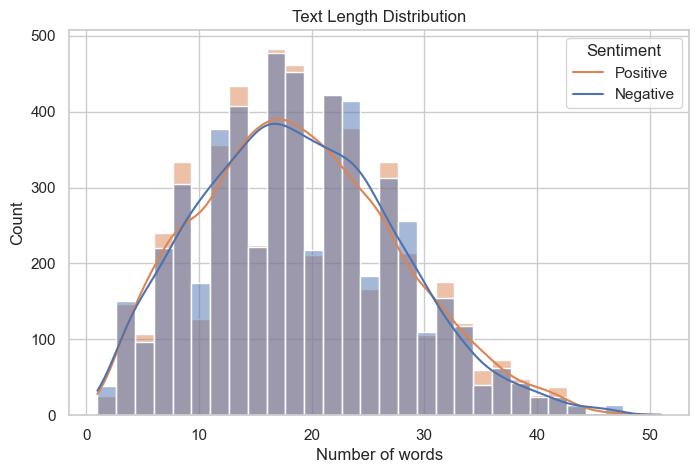

In [7]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="text_length",
    hue="label",
    bins=30,
    kde=True
)

plt.title("Text Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.legend(title="Sentiment", labels=["Positive", "Negative"])
plt.show()

### Train/test split


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train size: 8529
Test size: 2133

Train class distribution:
label
1    0.500059
0    0.499941
Name: proportion, dtype: float64

Test class distribution:
label
0    0.500234
1    0.499766
Name: proportion, dtype: float64


### Evaluation helper functions


In [9]:
def evaluate_model(
    model_name: str,
    y_true: pd.Series,
    y_pred: np.ndarray,
    y_proba: np.ndarray
) -> pd.DataFrame:
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

    return pd.DataFrame([metrics])


def plot_confusion_matrix(
    y_true: pd.Series,
    y_pred: np.ndarray,
    title: str
) -> None:
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )

    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()

### Model 1: TF-IDF + Logistic Regression


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

tfidf_lr_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        stop_words="english"
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

tfidf_lr_model.fit(X_train, y_train)

y_pred_tfidf = tfidf_lr_model.predict(X_test)
y_proba_tfidf = tfidf_lr_model.predict_proba(X_test)[:, 1]

tfidf_metrics = evaluate_model(
    model_name="TF-IDF + Logistic Regression",
    y_true=y_test,
    y_pred=y_pred_tfidf,
    y_proba=y_proba_tfidf
)

tfidf_metrics

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,TF-IDF + Logistic Regression,0.761838,0.761236,0.762664,0.761949,0.837823


### Confusion Matrix for TF-IDF model


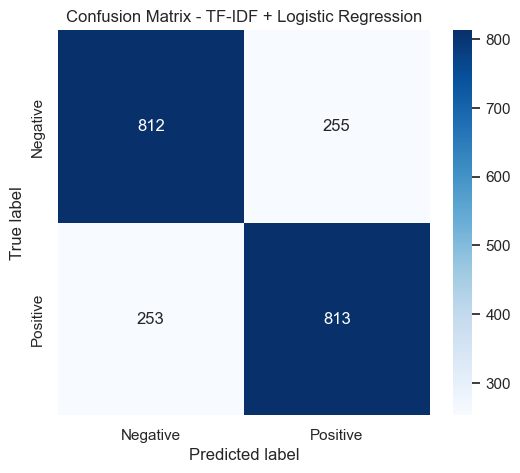

In [11]:
plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred_tfidf,
    title="Confusion Matrix - TF-IDF + Logistic Regression"
)

### Prepare tokenized data for Word2Vec


In [12]:
X_train_tokens = X_train.apply(tokenize_text)
X_test_tokens = X_test.apply(tokenize_text)

print("Train tokenized examples:")
print(X_train_tokens.head())

Train tokenized examples:
5209    [just, how, these, families, interact, may, su...
8463    [blue, crush, is, as, predictable, as, the, ti...
2623    [imagine, o, henry's, the, gift, of, the, magi...
606     [an, amusing, breezily, apolitical, documentar...
239     [it's, sort, of, a, st, century, morality, pla...
Name: clean_text, dtype: object


### Train Word2Vec model


In [13]:
from gensim.models import Word2Vec

word2vec_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    seed=RANDOM_STATE
)

print("Vocabulary size:", len(word2vec_model.wv))
print("Vector size:", word2vec_model.vector_size)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary size: 8936
Vector size: 100


### Convert texts to Word2Vec vectors


In [14]:
def text_to_vector(tokens: list[str], model: Word2Vec) -> np.ndarray:
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)


X_train_w2v = np.vstack([
    text_to_vector(tokens, word2vec_model)
    for tokens in X_train_tokens
])

X_test_w2v = np.vstack([
    text_to_vector(tokens, word2vec_model)
    for tokens in X_test_tokens
])

print("Train Word2Vec shape:", X_train_w2v.shape)
print("Test Word2Vec shape:", X_test_w2v.shape)

Train Word2Vec shape: (8529, 100)
Test Word2Vec shape: (2133, 100)


### Train Word2Vec + Logistic Regression model


In [15]:
w2v_lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

w2v_lr_model.fit(X_train_w2v, y_train)

y_pred_w2v = w2v_lr_model.predict(X_test_w2v)
y_proba_w2v = w2v_lr_model.predict_proba(X_test_w2v)[:, 1]

w2v_metrics = evaluate_model(
    model_name="Word2Vec + Logistic Regression",
    y_true=y_test,
    y_pred=y_pred_w2v,
    y_proba=y_proba_w2v
)

w2v_metrics

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Word2Vec + Logistic Regression,0.580872,0.579336,0.589118,0.584186,0.633636


### Confusion Matrix for Word2Vec model


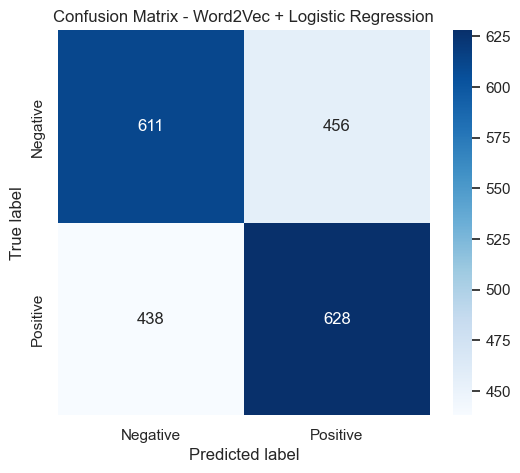

In [16]:
plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred_w2v,
    title="Confusion Matrix - Word2Vec + Logistic Regression"
)

### Model 3:Prepare data for DistilBERT fine-tuning


In [17]:
MAX_TRANSFORMER_TRAIN = 3000
MAX_TRANSFORMER_TEST = 1000

train_temp_df = pd.DataFrame({
    "text": X_train.values,
    "label": y_train.values
})

test_temp_df = pd.DataFrame({
    "text": X_test.values,
    "label": y_test.values
})

transformer_train_df, _ = train_test_split(
    train_temp_df,
    train_size=min(MAX_TRANSFORMER_TRAIN, len(train_temp_df)),
    random_state=RANDOM_STATE,
    stratify=train_temp_df["label"]
)

transformer_test_df, _ = train_test_split(
    test_temp_df,
    train_size=min(MAX_TRANSFORMER_TEST, len(test_temp_df)),
    random_state=RANDOM_STATE,
    stratify=test_temp_df["label"]
)

X_train_tr = transformer_train_df["text"].reset_index(drop=True)
y_train_tr = transformer_train_df["label"].reset_index(drop=True)

X_test_tr = transformer_test_df["text"].reset_index(drop=True)
y_test_tr = transformer_test_df["label"].reset_index(drop=True)

print("DistilBERT train size:", len(X_train_tr))
print("DistilBERT test size:", len(X_test_tr))

print("\nTrain label distribution:")
print(y_train_tr.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test_tr.value_counts(normalize=True))

DistilBERT train size: 3000
DistilBERT test size: 1000

Train label distribution:
label
0    0.5
1    0.5
Name: proportion, dtype: float64

Test label distribution:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


### Load DistilBERT tokenizer and model


In [18]:
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification
)

MODEL_NAME = "distilbert-base-uncased"

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print("Tokenizer and DistilBERT model loaded successfully.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizer and DistilBERT model loaded successfully.


### Tokenize texts for DistilBERT


In [19]:
train_encodings = tokenizer(
    X_train_tr.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test_tr.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

print("Train encodings keys:", list(train_encodings.keys()))
print("Test encodings keys:", list(test_encodings.keys()))

Train encodings keys: ['input_ids', 'attention_mask']
Test encodings keys: ['input_ids', 'attention_mask']


### Create PyTorch datasets for DistilBERT


In [20]:
from torch.utils.data import Dataset
import torch

class SentimentDataset(Dataset):
    def __init__(self, encodings: dict, labels: pd.Series):
        self.encodings = encodings
        self.labels = list(labels)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict:
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


train_dataset = SentimentDataset(train_encodings, y_train_tr)
test_dataset = SentimentDataset(test_encodings, y_test_tr)

print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 3000
Test dataset size: 1000


### Configure DistilBERT training


In [21]:
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


def compute_distilbert_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


training_args = TrainingArguments(
    output_dir="./distilbert_sentiment_results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./distilbert_logs",
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_distilbert_metrics
)

print("Trainer is ready.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer is ready.


### Fine-tune DistilBERT


In [22]:
train_result = trainer.train()

print("DistilBERT fine-tuning completed.")

c:\Users\User\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.423431,0.380757,0.838000,0.875556,0.788000,0.829474
2,0.260506,0.482653,0.847000,0.835590,0.864000,0.849558


c:\Users\User\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


DistilBERT fine-tuning completed.


### Evaluate DistilBERT model


In [23]:
distilbert_predictions = trainer.predict(test_dataset)

distilbert_logits = distilbert_predictions.predictions
y_pred_distilbert = np.argmax(distilbert_logits, axis=1)

y_proba_distilbert = torch.softmax(
    torch.tensor(distilbert_logits),
    dim=1
)[:, 1].numpy()

distilbert_metrics = evaluate_model(
    model_name="DistilBERT Fine-tuning",
    y_true=y_test_tr,
    y_pred=y_pred_distilbert,
    y_proba=y_proba_distilbert
)

distilbert_metrics

c:\Users\User\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,DistilBERT Fine-tuning,0.847,0.83559,0.864,0.849558,0.916892


### Confusion Matrix for DistilBERT


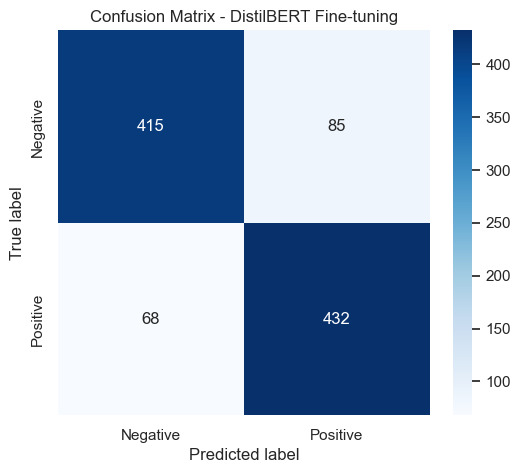

In [25]:
plot_confusion_matrix(
    y_true=y_test_tr,
    y_pred=y_pred_distilbert,
    title="Confusion Matrix - DistilBERT Fine-tuning"
)

### Plot DistilBERT training loss


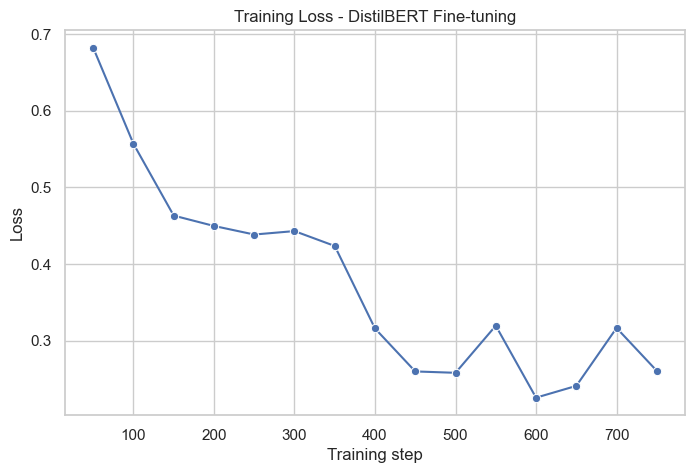

In [27]:
loss_df = pd.DataFrame(trainer.state.log_history)
loss_df = loss_df[loss_df["loss"].notna()][["step", "loss"]]

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=loss_df,   
    x="step",
    y="loss",
    marker="o"
)

plt.title("Training Loss - DistilBERT Fine-tuning")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.show()


### Final metrics comparison


In [28]:
results_df = pd.concat(
    [
        tfidf_metrics,
        w2v_metrics,
        distilbert_metrics
    ],
    ignore_index=True
)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,TF-IDF + Logistic Regression,0.761838,0.761236,0.762664,0.761949,0.837823
1,Word2Vec + Logistic Regression,0.580872,0.579336,0.589118,0.584186,0.633636
2,DistilBERT Fine-tuning,0.847000,0.835590,0.864000,0.849558,0.916892


### Bar chart comparison of model metrics


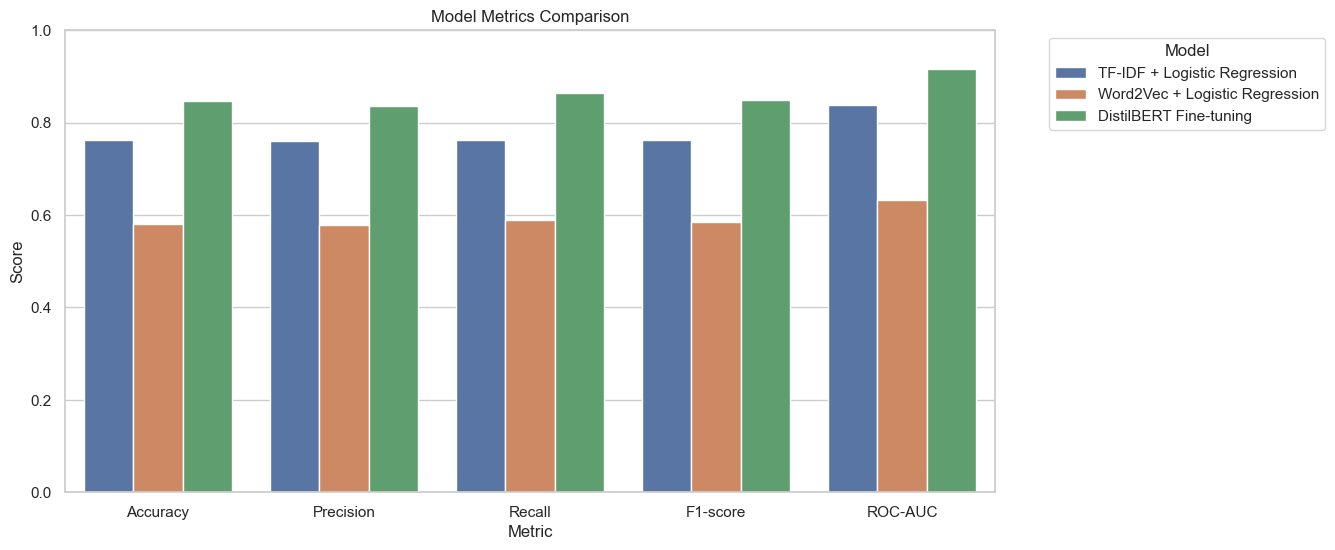

In [29]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

results_long = results_df.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Model Metrics Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### ROC-AUC curves


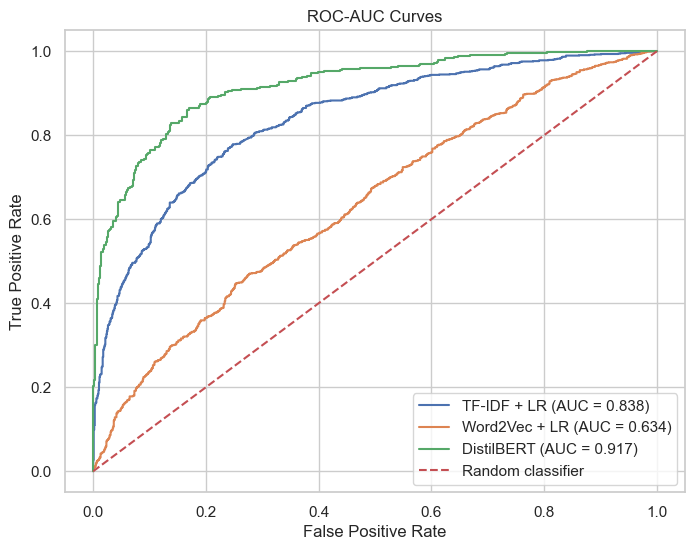

In [30]:
plt.figure(figsize=(8, 6))

fpr_tfidf, tpr_tfidf, _ = roc_curve(y_test, y_proba_tfidf)
fpr_w2v, tpr_w2v, _ = roc_curve(y_test, y_proba_w2v)
fpr_distilbert, tpr_distilbert, _ = roc_curve(y_test_tr, y_proba_distilbert)

plt.plot(
    fpr_tfidf,
    tpr_tfidf,
    label=f"TF-IDF + LR (AUC = {roc_auc_score(y_test, y_proba_tfidf):.3f})"
)

plt.plot(
    fpr_w2v,
    tpr_w2v,
    label=f"Word2Vec + LR (AUC = {roc_auc_score(y_test, y_proba_w2v):.3f})"
)

plt.plot(
    fpr_distilbert,
    tpr_distilbert,
    label=f"DistilBERT (AUC = {roc_auc_score(y_test_tr, y_proba_distilbert):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.title("ROC-AUC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### Error analysis


In [31]:
def show_errors(
    texts: pd.Series,
    y_true: pd.Series,
    y_pred: np.ndarray,
    model_name: str,
    n_examples: int = 5
) -> pd.DataFrame:
    errors_df = pd.DataFrame({
        "text": texts.reset_index(drop=True),
        "true_label": y_true.reset_index(drop=True),
        "predicted_label": y_pred
    })

    errors_df = errors_df[errors_df["true_label"] != errors_df["predicted_label"]]

    errors_df["true_sentiment"] = errors_df["true_label"].map({
        0: "Negative",
        1: "Positive"
    })

    errors_df["predicted_sentiment"] = errors_df["predicted_label"].map({
        0: "Negative",
        1: "Positive"
    })

    print(f"{model_name} errors:", len(errors_df))

    return errors_df[[
        "text",
        "true_sentiment",
        "predicted_sentiment"
    ]].head(n_examples)

### Show misclassified examples


In [32]:
tfidf_errors = show_errors(
    texts=X_test,
    y_true=y_test,
    y_pred=y_pred_tfidf,
    model_name="TF-IDF + Logistic Regression"
)

tfidf_errors

TF-IDF + Logistic Regression errors: 508


,text,true_sentiment,predicted_sentiment
5,the film makes a tragic error by going on for ...,Negative,Positive
14,while the plot follows a predictable connect t...,Positive,Negative
17,the film is saved from aren't kids cute sentim...,Positive,Negative
22,the most anti human big studio picture since m...,Negative,Positive
25,it has all the excitement of eating oatmeal,Negative,Positive


### Word2Vec misclassified examples


In [33]:
w2v_errors = show_errors(
    texts=X_test,
    y_true=y_test,
    y_pred=y_pred_w2v,
    model_name="Word2Vec + Logistic Regression"
)

w2v_errors

Word2Vec + Logistic Regression errors: 894


,text,true_sentiment,predicted_sentiment
0,all ends well sort of but the frenzied comic m...,Negative,Positive
1,from beginning to end this overheated melodram...,Negative,Positive
6,a glossy knock off of a b movie revenge flick,Negative,Positive
8,kim ki deok seems to have in mind an emotional...,Negative,Positive
10,what with the incessant lounge music playing i...,Negative,Positive


### DistilBERT misclassified examples


In [34]:
distilbert_errors = show_errors(
    texts=X_test_tr,
    y_true=y_test_tr,
    y_pred=y_pred_distilbert,
    model_name="DistilBERT Fine-tuning"
)

distilbert_errors

DistilBERT Fine-tuning errors: 153


,text,true_sentiment,predicted_sentiment
13,that the chuck norris grenade gag occurs about...,Negative,Positive
16,it's a bit disappointing that it only manages ...,Positive,Negative
17,at the end when the now computerized yoda fina...,Positive,Negative
20,a respectable venture on its own terms lacking...,Positive,Negative
21,the original wasn't a good movie but this rema...,Negative,Positive


## Conclusion

In this work, three different approaches for sentiment analysis were implemented and compared on the rt-polarity dataset.

The first model used a classical machine learning approach based on TF-IDF features and Logistic Regression. This model served as a strong baseline because TF-IDF represents important words and n-grams in numerical form.

The second model used Word2Vec embeddings with Logistic Regression. In this approach, each review was represented as an averaged word embedding vector. This method uses semantic word representations, but averaging word vectors may lose word order and some contextual meaning.

The third model used fine-tuning of DistilBERT, a Transformer-based model from the transformers library. This approach is more modern because it can capture contextual relationships between words better than classical vectorization methods.

The models were evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC. Confusion matrices were used to analyze correct and incorrect predictions, while ROC-AUC curves and bar charts helped compare the models visually. Additionally, error analysis showed examples where the models made incorrect predictions.

Overall, the experiment demonstrated that different text representation methods can lead to different classification quality. TF-IDF provides a simple and effective baseline, Word2Vec adds embedding-based semantic representation, and DistilBERT represents a modern Transformer-based approach for sentiment classification.